## 1. Imports & Setup

In [16]:
import numpy as np
import sep
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.patches import Ellipse
from astropy.io import fits

%matplotlib inline
rcParams['figure.figsize'] = [10., 8.]


## 2. Read the Image


In [17]:
# Read the FITS file
filename = 'hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits'

with fits.open(filename) as hdul:
    hdul.info()   # show what extensions are in the file
    # The science data is typically in extension 0 or 1
    # Try extension 0 first; if empty, use extension 1
    data = hdul[0].data
    if data is None:
        data = hdul[1].data
        print('Using extension 1 for science data.')
    else:
        print('Using extension 0 for science data.')
    header = hdul[0].header

print(f'Image shape: {data.shape}')
print(f'Data dtype:  {data.dtype}')

# ── Byte-order fix (required for SEP) ───────────────────────────────────────
# astropy.io.fits returns big-endian arrays; SEP requires native byte order
data = data.astype(data.dtype.newbyteorder('='))
print(f'After byte swap dtype: {data.dtype}  ✓')

Filename: hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (3600, 3600)   float32   
Using extension 0 for science data.
Image shape: (3600, 3600)
Data dtype:  >f4
After byte swap dtype: float32  ✓


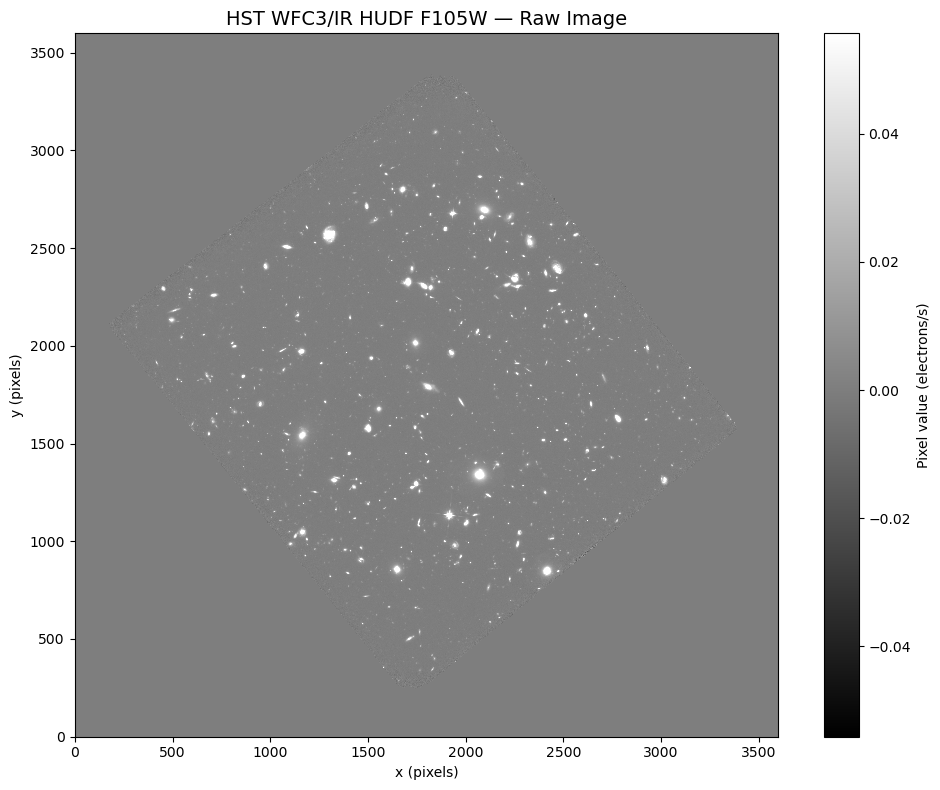

Image statistics:
  Mean  = 0.000791
  Std   = 0.054868
  Min   = -0.904729
  Max   = 74.446480


In [18]:
# Display the raw image
m, s = np.mean(data), np.std(data)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(data, interpolation='nearest', cmap='gray',
               vmin=m - s, vmax=m + s, origin='lower')
plt.colorbar(im, ax=ax, label='Pixel value (electrons/s)')
ax.set_title('HST WFC3/IR HUDF F105W — Raw Image', fontsize=14)
ax.set_xlabel('x (pixels)')
ax.set_ylabel('y (pixels)')
plt.tight_layout()
plt.show()

print(f'Image statistics:')
print(f'  Mean  = {m:.6f}')
print(f'  Std   = {s:.6f}')
print(f'  Min   = {data.min():.6f}')
print(f'  Max   = {data.max():.6f}')

## 3. Background Estimation & Subtraction



In [19]:
# Measure spatially varying background
# bw, bh = background box width/height (pixels)
# fw, fh = filter width/height (in boxes) for smoothing
bkg = sep.Background(data, bw=64, bh=64, fw=3, fh=3)

# Global background statistics
print(f'Global background level (mean): {bkg.globalback:.6f}')
print(f'Global background RMS (noise):  {bkg.globalrms:.6f}')

Global background level (mean): 0.000000
Global background RMS (noise):  0.000540


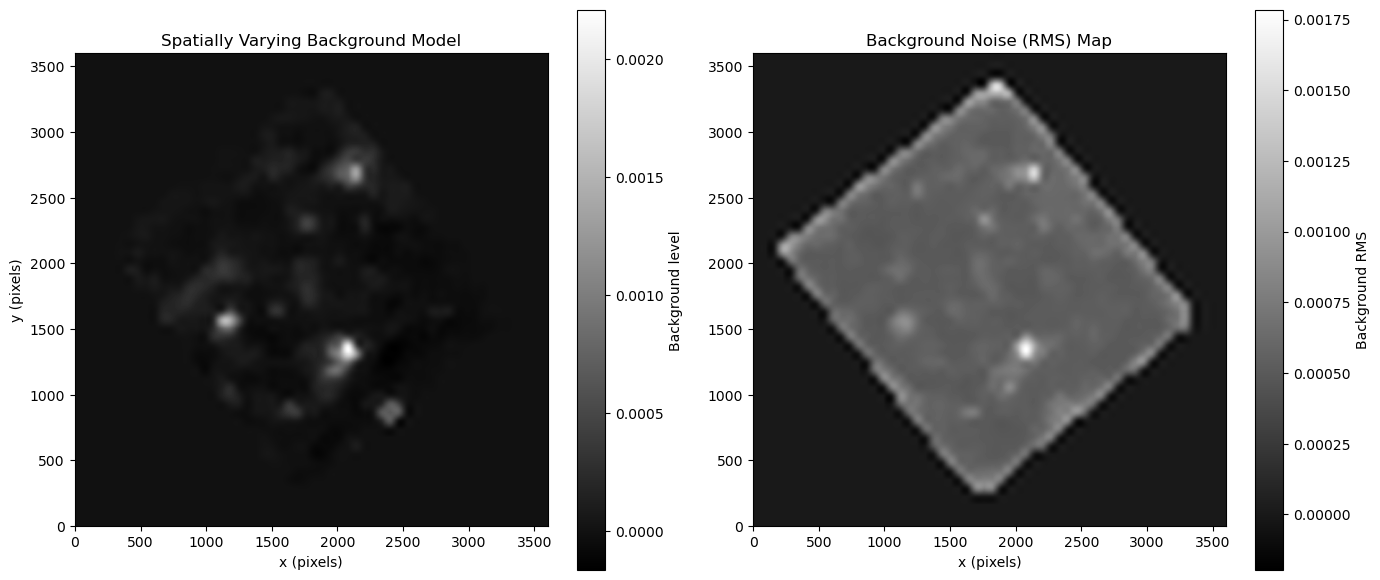

In [20]:
# Visualize the background model
bkg_image = bkg.back()   # 2D background array
bkg_rms   = bkg.rms()    # 2D background RMS array

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar(im0, ax=axes[0], label='Background level')
axes[0].set_title('Spatially Varying Background Model')
axes[0].set_xlabel('x (pixels)')
axes[0].set_ylabel('y (pixels)')

im1 = axes[1].imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar(im1, ax=axes[1], label='Background RMS')
axes[1].set_title('Background Noise (RMS) Map')
axes[1].set_xlabel('x (pixels)')

plt.tight_layout()
plt.show()

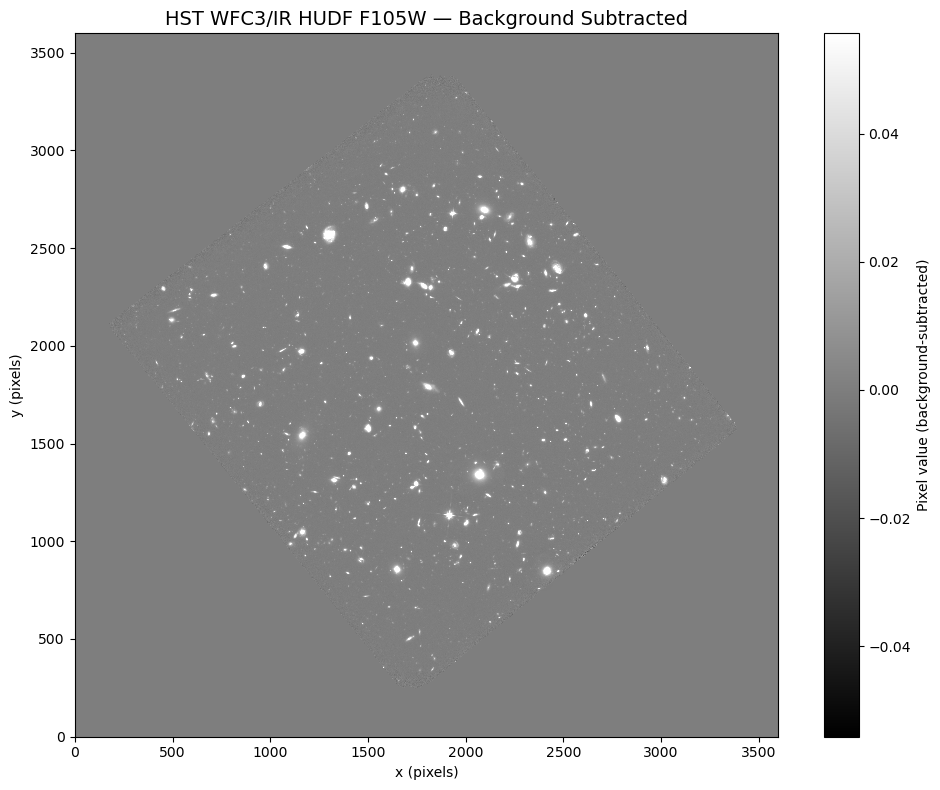

Background-subtracted image:
  Mean ≈ 0.000772  (should be ~0 after subtraction)
  RMS  = 0.054864


In [21]:
# Subtract the background
data_sub = data - bkg

# Display background-subtracted image
m2, s2 = np.mean(data_sub), np.std(data_sub)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m2 - s2, vmax=m2 + s2, origin='lower')
plt.colorbar(im, ax=ax, label='Pixel value (background-subtracted)')
ax.set_title('HST WFC3/IR HUDF F105W — Background Subtracted', fontsize=14)
ax.set_xlabel('x (pixels)')
ax.set_ylabel('y (pixels)')
plt.tight_layout()
plt.show()

print(f'Background-subtracted image:')
print(f'  Mean ≈ {m2:.6f}  (should be ~0 after subtraction)')
print(f'  RMS  = {s2:.6f}')

## 4. Source Detection


In [22]:
# Detect sources at 1.5-sigma above background
objects = sep.extract(data_sub, thresh=1.5, err=bkg.globalrms)

print(f'Number of sources detected: {len(objects)}')
print(f'\nAvailable object fields:')
print(objects.dtype.names)

Number of sources detected: 8640

Available object fields:
('thresh', 'npix', 'tnpix', 'xmin', 'xmax', 'ymin', 'ymax', 'x', 'y', 'x2', 'y2', 'xy', 'errx2', 'erry2', 'errxy', 'a', 'b', 'theta', 'cxx', 'cyy', 'cxy', 'cflux', 'flux', 'cpeak', 'peak', 'xcpeak', 'ycpeak', 'xpeak', 'ypeak', 'flag')


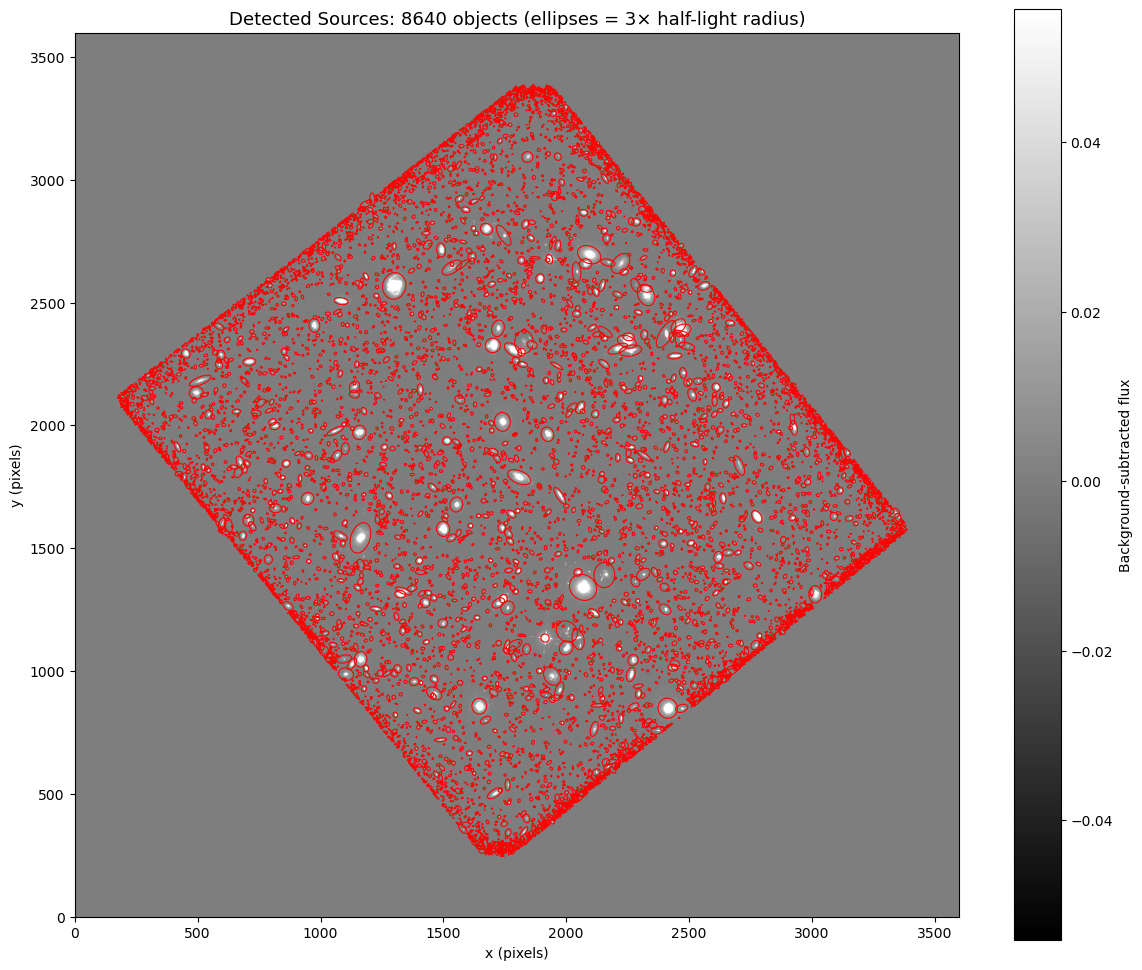

In [23]:
# Overplot detected objects on the image as ellipses
fig, ax = plt.subplots(figsize=(12, 10))
m2, s2 = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m2 - s2, vmax=m2 + s2, origin='lower')
plt.colorbar(im, ax=ax, label='Background-subtracted flux')

# Draw an ellipse for each detected object
for i in range(len(objects)):
    e = Ellipse(
        xy=(objects['x'][i], objects['y'][i]),
        width=6 * objects['a'][i],
        height=6 * objects['b'][i],
        angle=objects['theta'][i] * 180. / np.pi
    )
    e.set_facecolor('none')
    e.set_edgecolor('red')
    e.set_linewidth(0.8)
    ax.add_artist(e)

ax.set_title(f'Detected Sources: {len(objects)} objects (ellipses = 3× half-light radius)', fontsize=13)
ax.set_xlabel('x (pixels)')
ax.set_ylabel('y (pixels)')
plt.tight_layout()
plt.show()

## 5. Aperture Photometry



In [24]:
# Circular aperture photometry: 3-pixel radius at each object centroid
flux, fluxerr, flag = sep.sum_circle(
    data_sub,
    objects['x'], objects['y'],
    3.0,                   # aperture radius in pixels
    err=bkg.globalrms,     # background noise for error estimation
    gain=1.0               # CCD gain (e-/ADU); assume 1.0
)

print('Aperture photometry complete.')
print(f'  Total objects measured: {len(flux)}')
print(f'  Objects with flag=0 (clean): {(flag==0).sum()}')
print()
print('First 10 objects:')
print(f'{"Object":>8}  {"Flux":>14}  {"Flux Error":>14}  {"Flag":>6}')
print('-' * 50)
for i in range(min(10, len(flux))):
    print(f'{i:>8d}  {flux[i]:>14.3f}  {fluxerr[i]:>14.3f}  {flag[i]:>6d}')

Aperture photometry complete.
  Total objects measured: 8640
  Objects with flag=0 (clean): 8640

First 10 objects:
  Object            Flux      Flux Error    Flag
--------------------------------------------------
       0           0.031           0.177       0
       1           0.031           0.176       0
       2          -0.024           0.003       0
       3           0.002           0.044       0
       4           0.012           0.112       0
       5          -0.011           0.003       0
       6           0.029           0.171       0
       7          -0.009           0.003       0
       8           0.048           0.219       0
       9           0.028           0.167       0


---
## 6. Analysis Questions

### Q1: How many sources (stars/galaxies) were found? Histogram their fluxes.
### Q2: What are the mean, median, and standard deviation of the flux distribution?
### Q3: What is the largest outlier, and how many standard deviations is it from the mean?

Q1: Number of detected sources = 8640

    Clean sources (flag=0): 8640
    Flagged sources:        0


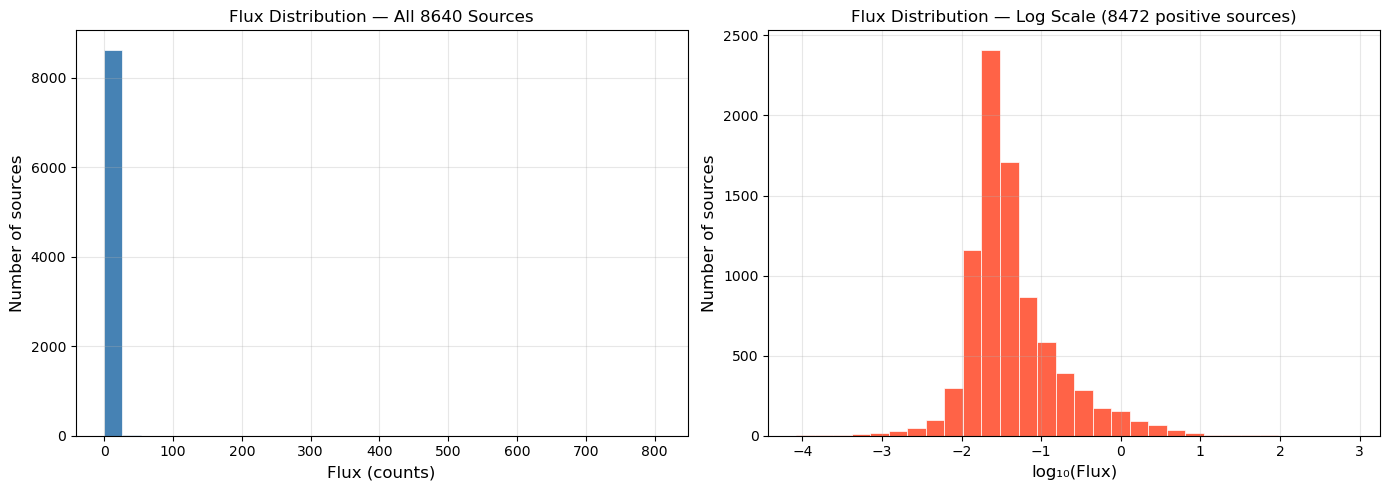

Histogram saved as flux_histogram.png


In [25]:
# ── Q1: Number of sources & flux histogram ───────────────────────────────────

print(f'Q1: Number of detected sources = {len(flux)}')
print()

# Use only clean detections (flag == 0) for the histogram
flux_clean = flux[flag == 0]
print(f'    Clean sources (flag=0): {len(flux_clean)}')
print(f'    Flagged sources:        {(flag != 0).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: all flux values
axes[0].hist(flux, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Flux (counts)', fontsize=12)
axes[0].set_ylabel('Number of sources', fontsize=12)
axes[0].set_title(f'Flux Distribution — All {len(flux)} Sources', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Right panel: log scale to show dynamic range better
# Clip to positive flux only for log scale
flux_pos = flux[flux > 0]
axes[1].hist(np.log10(flux_pos), bins=30, color='tomato', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('log₁₀(Flux)', fontsize=12)
axes[1].set_ylabel('Number of sources', fontsize=12)
axes[1].set_title(f'Flux Distribution — Log Scale ({len(flux_pos)} positive sources)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('flux_histogram.png', bbox_inches='tight', dpi=120)
plt.show()
print('Histogram saved as flux_histogram.png')

In [26]:
# ── Q2: Mean, median, standard deviation of flux distribution ───────────────

flux_mean   = np.mean(flux)
flux_median = np.median(flux)
flux_std    = np.std(flux)

print('Q2: Flux distribution statistics')
print(f'    Mean              = {flux_mean:.4f} counts')
print(f'    Median            = {flux_median:.4f} counts')
print(f'    Standard deviation = {flux_std:.4f} counts')
print()
print('Interpretation:')
print(f'  The mean ({flux_mean:.1f}) is likely much higher than the median ({flux_median:.1f}),')
print(f'  indicating the distribution is right-skewed — a few very bright sources')
print(f'  pull the mean up significantly above the typical source flux.')

Q2: Flux distribution statistics
    Mean              = 0.3619 counts
    Median            = 0.0310 counts
    Standard deviation = 9.2435 counts

Interpretation:
  The mean (0.4) is likely much higher than the median (0.0),
  indicating the distribution is right-skewed — a few very bright sources
  pull the mean up significantly above the typical source flux.


In [ ]:
# ── Q3: Largest outlier — how many standard deviations from the mean? ────────

max_flux       = np.max(flux)
max_flux_idx   = np.argmax(flux)
n_sigma        = (max_flux - flux_mean) / flux_std

print('Q3: Largest flux outlier')
print(f'    Object index      = {max_flux_idx}')
print(f'    Maximum flux      = {max_flux:.4f} counts')
print(f'    Mean flux         = {flux_mean:.4f} counts')
print(f'    Std dev           = {flux_std:.4f} counts')
print()
print(f'    Significance = (max - mean) / std')
print(f'                 = ({max_flux:.2f} - {flux_mean:.2f}) / {flux_std:.2f}')
print(f'                 = {n_sigma:.2f} standard deviations from the mean')
print()
print(f'    Position: x = {objects["x"][max_flux_idx]:.1f}, y = {objects["y"][max_flux_idx]:.1f} pixels')

# Visualize the outlier on the image
fig, ax = plt.subplots(figsize=(10, 8))
m2, s2 = np.mean(data_sub), np.std(data_sub)
ax.imshow(data_sub, interpolation='nearest', cmap='gray',
          vmin=m2 - s2, vmax=m2 + s2, origin='lower')

# Mark all objects in red, brightest in yellow
for i in range(len(objects)):
    color = 'yellow' if i == max_flux_idx else 'red'
    lw    = 2.0      if i == max_flux_idx else 0.7
    e = Ellipse(
        xy=(objects['x'][i], objects['y'][i]),
        width=6 * objects['a'][i],
        height=6 * objects['b'][i],
        angle=objects['theta'][i] * 180. / np.pi
    )
    e.set_facecolor('none')
    e.set_edgecolor(color)
    e.set_linewidth(lw)
    ax.add_artist(e)

ax.annotate(
    f'Brightest source\n({n_sigma:.1f}σ from mean)',
    xy=(objects['x'][max_flux_idx], objects['y'][max_flux_idx]),
    xytext=(objects['x'][max_flux_idx] + 40, objects['y'][max_flux_idx] + 40),
    color='yellow', fontsize=10,
    arrowprops=dict(arrowstyle='->', color='yellow', lw=1.5)
)

ax.set_title(f'Sources Detected — Brightest Outlier Highlighted (yellow)', fontsize=13)
ax.set_xlabel('x (pixels)')
ax.set_ylabel('y (pixels)')
plt.tight_layout()
plt.savefig('outlier_map.png', bbox_inches='tight', dpi=120)
plt.show()
print('Outlier map saved as outlier_map.png')

Q3: Largest flux outlier
    Object index      = 2066
    Maximum flux      = 807.2973 counts
    Mean flux         = 0.3619 counts
    Std dev           = 9.2435 counts

    Significance = (max - mean) / std
                 = (807.30 - 0.36) / 9.24
                 = 87.30 standard deviations from the mean

    Position: x = 1914.3, y = 1134.3 pixels


In [ ]:
# ── Final summary ────────────────────────────────────────────────────────────
print('=' * 55)
print('  SUMMARY')
print('=' * 55)
print(f'  Image:          {filename}')
print(f'  Image size:     {data.shape}')
print(f'  Background:     {bkg.globalback:.6f} (global mean)')
print(f'  Background RMS: {bkg.globalrms:.6f}')
print()
print(f'  Q1: Sources detected:       {len(flux)}')
print(f'  Q2: Flux mean:              {flux_mean:.2f} counts')
print(f'      Flux median:            {flux_median:.2f} counts')
print(f'      Flux std dev:           {flux_std:.2f} counts')
print(f'  Q3: Brightest source flux:  {max_flux:.2f} counts')
print(f'      Significance:           {n_sigma:.2f} sigma from mean')
print('=' * 55)

  SUMMARY
  Image:          hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits
  Image size:     (3600, 3600)
  Background:     0.000000 (global mean)
  Background RMS: 0.000540

  Q1: Sources detected:       8640
  Q2: Flux mean:              0.36 counts
      Flux median:            0.03 counts
      Flux std dev:           9.24 counts
  Q3: Brightest source flux:  807.30 counts
      Significance:           87.30 sigma from mean
